#  CHALLENGE DATA 

**Cours : Machine Learning — Projet Data | IFIE2 Données**  
**Auteur : Fresnel KENGNE - Carlos SIBEFEU**



## Maladie de Parkinson : Prédire et Corriger les Biais dans l'Évaluation du Score Moteur par Institut du Cerveau

## 0. Imports et chargement des données

In [1]:
#! pip install xgboost

import numpy as np
import pandas as pd

# pour réaliser des visualisations
import matplotlib.pyplot as plt
import seaborn as sns


# geographiques
#from shapely.geometry import Point
#import geopandas as gpd
#from geopandas import GeoDataFrame
#import geoplot

# pour pré-traiter les données
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder



from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb


In [2]:
# Chargement du jeu de données

X_train = pd.read_csv("données/X_train_6ZIKlTY.csv")
y_train = pd.read_csv("données/y_train_lXj6X5y.csv")
X_test = pd.read_csv("données/X_test_oiZ2ukx.csv")

In [3]:
X_train.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN
3,3,IPLP5212,A,0,LRRK2+,48.5,54.8,770.0,1.5,NaN,11.0,NaN
4,4,IPLP5212,A,0,LRRK2+,48.5,56.9,885.0,0.3,NaN,24.0,NaN


In [4]:
y_train.head()

,Index,target
0,0,34.7
1,1,38.1
2,2,41.6
3,3,44.9
4,4,52.0


In [5]:
X_test.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
0,0,KQYS2327,A,1,NaN,43.8,48.5,791.0,1.7,NaN,25.0,NaN,4.7
1,1,KQYS2327,A,1,NaN,43.8,49.1,826.0,2.8,NaN,25.0,NaN,5.3
2,2,KQYS2327,A,1,NaN,43.8,49.5,848.0,0.7,13.8,33.0,41.0,5.7
3,3,KQYS2327,A,1,NaN,43.8,50.0,874.0,5.2,NaN,34.0,NaN,6.2
4,4,KQYS2327,A,1,NaN,43.8,50.8,924.0,3.4,13.7,30.0,47.0,7.0


### Explication des features

| Index                     | Description |
|---------------------------|-------------|
| Index                     | Index |
| patient_id                | ID Patient |
| cohort                    | ID Cohorte (groupe) |
| sexM                      | Genre |
| gene                      | Marqueurs génétiques |
| age_at_diagnosis          | Âge au moment du diagnostique |
| age                       | Âge |
| ledd                      | Posologie médicament lévodopa en dose quotidienne équivalente (LEDD) |
| time_since_intake_on      | Délai depuis dernière prise de médicament pour Score ON |
| time_since_intake_off     | Délai depuis dernière prise de médicament pour Score OFF |
| on                        | Score ON |
| off                       | Score OFF |
| time_since_diagnosis      | Temps écoulé depuis le diagnostic |

## 1. Exploration du Jeu de Données


In [6]:
# On vérifie la taille des dataset
X_train.shape, y_train.shape, X_test.shape

((55603, 12), (55603, 2), (23672, 13))

In [7]:
# Informations sur le dataset
X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  55603 non-null  int64  
 1   patient_id             55603 non-null  object 
 2   cohort                 55603 non-null  object 
 3   sexM                   55603 non-null  int64  
 4   gene                   37645 non-null  object 
 5   age_at_diagnosis       52773 non-null  float64
 6   age                    55603 non-null  float64
 7   ledd                   35010 non-null  float64
 8   time_since_intake_on   29663 non-null  float64
 9   time_since_intake_off  11775 non-null  float64
 10  on                     38944 non-null  float64
 11  off                    32196 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 5.1+ MB


In [8]:
# Pourcentage de valeurs nulles par colonnes
(X_train.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.823085
time_since_intake_on     46.652159
off                      42.096649
ledd                     37.035771
gene                     32.296819
on                       29.960614
age_at_diagnosis          5.089653
Index                     0.000000
patient_id                0.000000
cohort                    0.000000
sexM                      0.000000
age                       0.000000
dtype: float64

In [9]:
X_train["gene"].unique()

array(['LRRK2+', 'No Mutation', nan, 'GBA+', 'OTHER+'], dtype=object)

In [10]:
X_test["gene"].unique()

array([nan, 'No Mutation', 'LRRK2+', 'GBA+', 'OTHER+'], dtype=object)

In [11]:
(X_test.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.747043
time_since_intake_on     47.296384
off                      41.272389
ledd                     37.449307
gene                     32.794018
on                       30.686043
Index                     0.000000
patient_id                0.000000
cohort                    0.000000
sexM                      0.000000
age_at_diagnosis          0.000000
age                       0.000000
time_since_diagnosis      0.000000
dtype: float64

In [12]:
y_train.isnull().sum()

Index     0
target    0
dtype: int64

Notre dataset de variables cibles ne contient pas de valeurs nulles.

In [13]:
# Description des datasets
X_train.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
count,55603.000000,55603.000000,52773.000000,55603.000000,35010.000000,29663.000000,11775.000000,38944.000000,32196.000000
mean,27801.000000,0.596353,56.734648,62.516422,638.102228,1.953717,14.199448,21.985980,26.295316
std,16051.347846,0.490633,10.823093,11.484480,219.443182,1.168793,2.844782,10.371291,16.534567
min,0.000000,0.000000,16.500000,16.500000,50.000000,0.000000,6.900000,0.000000,0.000000
25%,13900.500000,0.000000,49.500000,54.900000,481.000000,1.100000,12.200000,14.000000,13.000000
50%,27801.000000,1.000000,56.900000,62.500000,611.000000,1.600000,13.800000,21.000000,24.000000
75%,41701.500000,1.000000,64.400000,70.500000,765.000000,2.600000,15.700000,28.000000,38.000000
max,55602.000000,1.000000,89.900000,103.300000,1796.000000,6.300000,25.100000,95.000000,106.000000


In [14]:
X_test.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
count,23672.000000,23672.000000,23672.000000,23672.000000,14807.000000,12476.000000,5031.000000,16408.000000,13902.000000,23672.000000
mean,11835.500000,0.615960,56.393545,62.099159,637.611332,1.958216,14.135202,22.233057,26.316070,5.705615
std,6833.662122,0.486378,10.426912,11.333973,214.153023,1.172925,2.853948,10.736239,16.851214,4.455499
min,0.000000,0.000000,18.800000,19.100000,50.000000,0.000000,7.300000,0.000000,0.000000,-28.695144
25%,5917.750000,0.000000,49.600000,54.400000,486.000000,1.100000,12.200000,14.000000,13.000000,2.600000
50%,11835.500000,1.000000,56.295144,61.900000,616.000000,1.600000,13.800000,21.000000,24.000000,5.200000
75%,17753.250000,1.000000,63.600000,70.100000,764.500000,2.600000,15.600000,29.000000,37.750000,8.404856
max,23671.000000,1.000000,83.200000,100.600000,1562.000000,6.400000,25.000000,93.000000,108.000000,33.204856


In [15]:
X_test = X_test.drop(columns=["time_since_diagnosis","Index","patient_id"])

In [16]:
y_train.describe()

,Index,target
count,55603.000000,55603.000000
mean,27801.000000,37.331606
std,16051.347846,16.504326
min,0.000000,0.000000
25%,13900.500000,25.400000
50%,27801.000000,37.100000
75%,41701.500000,49.200000
max,55602.000000,109.500000


Au vu de tout ce traitement, on pourrait : 
- Effacer les données manquantes
- Les remplacer par la médiane
- Effacer les colonnes qui semblent nous servir à rien: index, patientid, cohort, age(car on a deja l'ae de diagnostic et la durée entre cette date et la prise de l'enregistrement)
- Effacer le sexe puis travailler avec


In [17]:
#Concatenation de X_train et y_train
df = pd.concat([X_train, y_train], axis=1)
df.shape

(55603, 14)

In [18]:
#Suppression des colonnes inutiles
df = df.drop(columns=["Index","patient_id"])
df.shape

(55603, 11)

In [19]:
df.head()

,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,target
0,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN,34.7
1,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0,38.1
2,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN,41.6
3,A,0,LRRK2+,48.5,54.8,770.0,1.5,NaN,11.0,NaN,44.9
4,A,0,LRRK2+,48.5,56.9,885.0,0.3,NaN,24.0,NaN,52.0


In [20]:
#tableau de correlation des variables numeriques
dfNum = df.drop(columns=["cohort","gene"])
dfNum.corr()

,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,target
sexM,1.000000,0.014815,0.010389,-0.018867,0.005180,-0.002611,0.020936,-0.002773,-0.001603
age_at_diagnosis,0.014815,1.000000,0.941416,-0.160554,-0.004835,0.004601,0.038912,0.122826,0.127892
age,0.010389,0.941416,1.000000,0.076056,-0.003806,0.009428,0.124102,0.253538,0.304531
ledd,-0.018867,-0.160554,0.076056,1.000000,-0.001576,0.024608,0.211127,0.227920,0.299595
time_since_intake_on,0.005180,-0.004835,-0.003806,-0.001576,1.000000,0.006807,-0.220349,-0.008982,0.002087
time_since_intake_off,-0.002611,0.004601,0.009428,0.024608,0.006807,1.000000,0.002520,0.038192,0.011191
on,0.020936,0.038912,0.124102,0.211127,-0.220349,0.002520,1.000000,0.867842,0.687351
off,-0.002773,0.122826,0.253538,0.227920,-0.008982,0.038192,0.867842,1.000000,0.885098
target,-0.001603,0.127892,0.304531,0.299595,0.002087,0.011191,0.687351,0.885098,1.000000


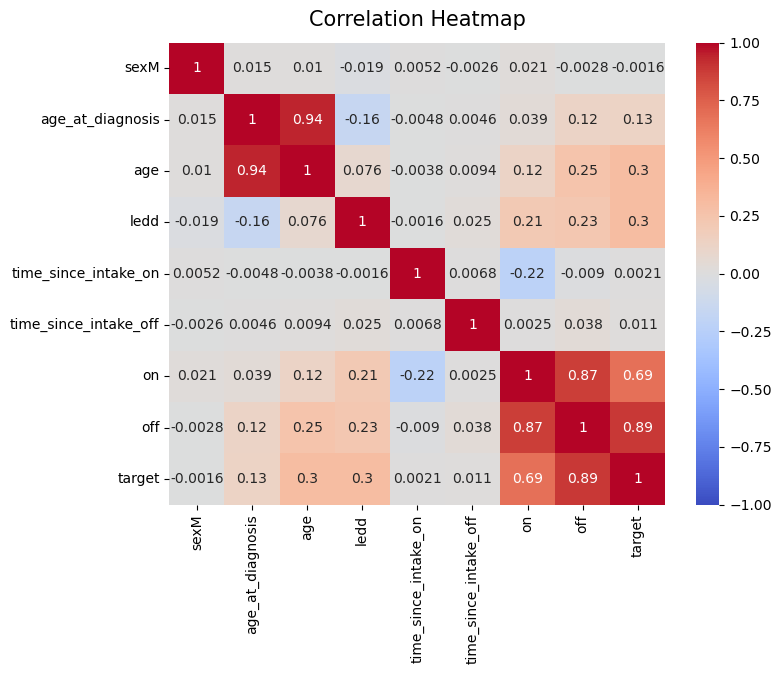

In [21]:
#Graphique visuelle du tableau de correlation
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(dfNum.corr(),cmap= "coolwarm" ,vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':15}, pad=12);

In [22]:
# Split en cours de telechargement

y = df["target"]
X = df.drop(columns=["target"])

# On sépare le jeu de données en jeu d'entraînement et en jeu de test
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)
# On vérifie la taille de chacun des jeux = leur somme doit être égale au jeu de départ

X_tr.shape, X_ts.shape,y_tr.shape,y_ts.shape

((44482, 10), (11121, 10), (44482,), (11121,))

## 2. Feature engineering 



In [23]:
##Gestion des valeurs manquantes (Mediane)

#valeurs numeriques
num_cols = X_tr.select_dtypes(include=np.number).columns
medians = X_tr[num_cols].median()

X_tr[num_cols]= X_tr[num_cols].fillna(medians)
X_ts[num_cols]= X_ts[num_cols].fillna(medians)
X_test[num_cols]= X_test[num_cols].fillna(medians)

#valeurs categorielles
cat_cols= X_tr.select_dtypes(exclude=np.number).columns
modes= X_tr[cat_cols].mode().iloc[0]

X_tr[cat_cols]= X_tr[cat_cols].fillna(modes)
X_ts[cat_cols]= X_ts[cat_cols].fillna(modes)
X_test[cat_cols]= X_test[cat_cols].fillna(modes)

X_tr.isna().sum()

cohort                   0
sexM                     0
gene                     0
age_at_diagnosis         0
age                      0
ledd                     0
time_since_intake_on     0
time_since_intake_off    0
on                       0
off                      0
dtype: int64

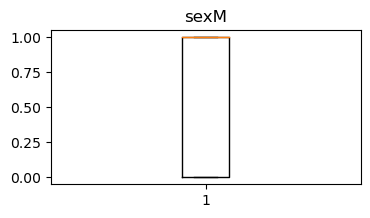

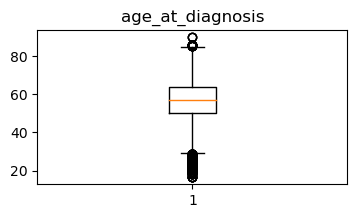

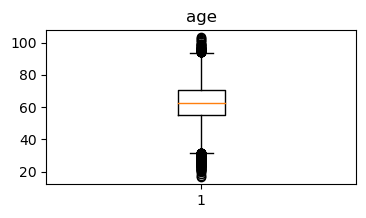

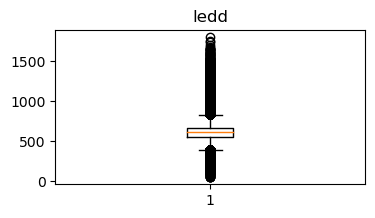

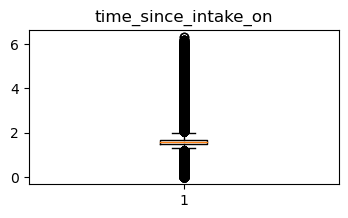

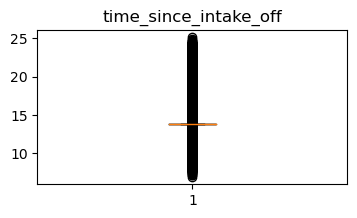

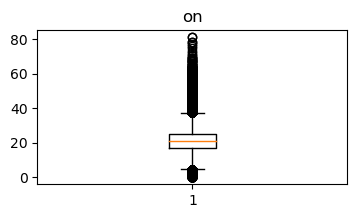

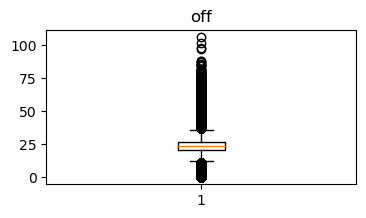

In [24]:
#Boxplot pour visualiser les valeurs aberrantes

num_cols = X_tr.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_tr[col])
    plt.title(col)
    plt.show()

In [25]:
# Gestion des valeurs aberrantes (winsorization)
Q1 = X_tr[num_cols].quantile(0.25)
Q3 = X_tr[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping sur train et test avec les mêmes bornes
X_tr[num_cols] = X_tr[num_cols].clip(lower=lower, upper=upper, axis=1)
X_ts[num_cols] = X_ts[num_cols].clip(lower=lower, upper=upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower=lower, upper=upper, axis=1)

X_tr[num_cols].describe()

,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
count,44482.000000,44482.000000,44482.000000,44482.000000,44482.000000,4.448200e+04,44482.000000,44482.000000
mean,0.597523,56.799278,62.561040,615.389281,1.608174,1.380000e+01,21.331932,24.175846
std,0.490403,10.428137,11.400312,122.224917,0.258771,2.238235e-13,7.557741,7.420247
min,0.000000,29.000000,31.500000,392.000000,1.200000,1.380000e+01,5.000000,12.000000
25%,0.000000,50.000000,54.900000,557.000000,1.500000,1.380000e+01,17.000000,21.000000
50%,1.000000,56.900000,62.500000,612.000000,1.600000,1.380000e+01,21.000000,24.000000
75%,1.000000,64.000000,70.500000,667.000000,1.700000,1.380000e+01,25.000000,27.000000
max,1.000000,85.000000,93.900000,832.000000,2.000000,1.380000e+01,37.000000,36.000000


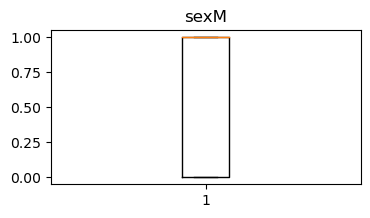

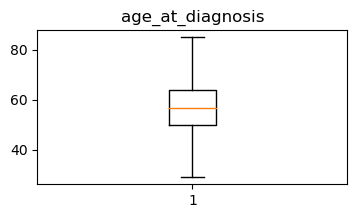

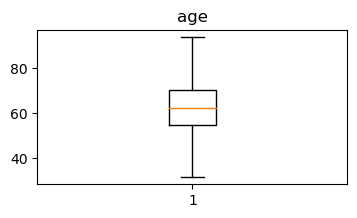

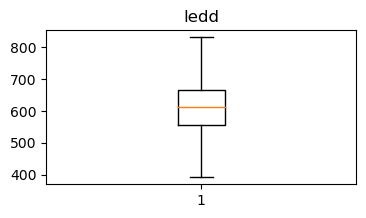

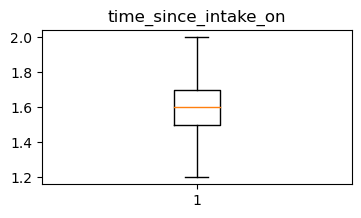

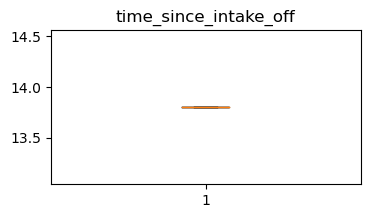

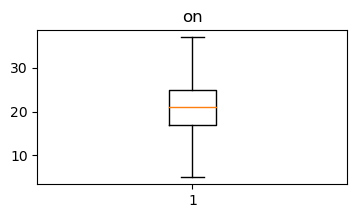

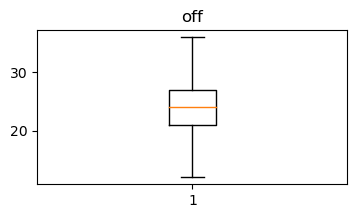

In [26]:
#verification
num_cols = X_tr.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_tr[col])
    plt.title(col)
    plt.show()

In [27]:
##Gestion des variables categorielles

# Colonnes qui nous intéressent
cat_cols_shit = ["cohort","gene"]

# Initialisation de l'encoder
shit = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
shit.fit(X_tr[cat_cols_shit])

train_ohe = pd.DataFrame(
    shit.transform(X_tr[cat_cols_shit]),
    index=X_tr.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)

test_ohe = pd.DataFrame(
    shit.transform(X_ts[cat_cols_shit]),
    index=X_ts.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)
test_high = pd.DataFrame(
    shit.transform(X_test[cat_cols_shit]),
    index=X_test.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)

X_tr = X_tr.drop(columns=cat_cols_shit).join(train_ohe)
X_ts  = X_ts.drop(columns=cat_cols_shit).join(test_ohe)
X_test  = X_test.drop(columns=cat_cols_shit).join(test_high)

X_tr.shape, X_ts.shape

((44482, 14), (11121, 14))

In [28]:
X_tr.head()

,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,cohort_A,cohort_B,gene_GBA+,gene_LRRK2+,gene_No Mutation,gene_OTHER+
44464,1,69.2,72.8,609.0,1.6,13.8,20.0,24.0,1.0,0.0,0.0,0.0,1.0,0.0
38133,1,63.3,70.7,752.0,1.2,13.8,37.0,36.0,1.0,0.0,0.0,1.0,0.0,0.0
30901,0,56.8,66.0,810.0,1.2,13.8,37.0,24.0,1.0,0.0,0.0,1.0,0.0,0.0
53334,1,40.3,46.5,774.0,2.0,13.8,11.0,24.0,1.0,0.0,1.0,0.0,0.0,0.0
32070,0,65.2,68.0,434.0,1.5,13.8,13.0,24.0,1.0,0.0,0.0,0.0,1.0,0.0


In [29]:
#bien propre , bien soigné
X_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44482 entries, 44464 to 15795
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sexM                   44482 non-null  int64  
 1   age_at_diagnosis       44482 non-null  float64
 2   age                    44482 non-null  float64
 3   ledd                   44482 non-null  float64
 4   time_since_intake_on   44482 non-null  float64
 5   time_since_intake_off  44482 non-null  float64
 6   on                     44482 non-null  float64
 7   off                    44482 non-null  float64
 8   cohort_A               44482 non-null  float64
 9   cohort_B               44482 non-null  float64
 10  gene_GBA+              44482 non-null  float64
 11  gene_LRRK2+            44482 non-null  float64
 12  gene_No Mutation       44482 non-null  float64
 13  gene_OTHER+            44482 non-null  float64
dtypes: float64(13), int64(1)
memory usage: 6.1 MB


In [30]:
#Standardisation bien soigné
scaler = StandardScaler()

X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
X_ts[num_cols] = scaler.transform(X_ts[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

---

## 3. Linear Regression & XGBOOST




In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_ts)
rmse_lr = root_mean_squared_error(y_ts, y_pred_lr)
print(f'Linear Regression RMSE : {rmse_lr:.4f}')

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'reg:squarederror',
    eval_metric           = 'rmse',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_ts, y_ts)], verbose=False)
y_pred_xgb = xgb_model.predict(X_ts)
rmse_xgb = root_mean_squared_error(y_ts, y_pred_xgb)
print(f'XGBoost RMSE            : {rmse_xgb:.4f}')

In [32]:
# Prédictions avec le meilleur modèle (ex : XGBoost)
y_test = xgb_model.predict(X_test)

# Créer un dataset avec les prédictions
df_predictions = pd.DataFrame({
    "id": X_test.index,
    "y_test": y_test
})

# Sauvegarder en CSV
df_predictions.to_csv("y_test_predictions.csv", index=False)

print("Fichier y_test_predictions.csv généré.")

Fichier y_test_predictions.csv généré.


Score sur le site de 65; c'est là;